### 목표 설정
- knn 알고리즘을 통해서 붓꽃 품종을 분류해보자
- 머신러닝 모델을 사용하는 방법에 익숙해져보자.
- 하이퍼 파라미터 튜닝을 진행해보자.
- 과대 / 과소적합 / 일반화 상황을 판단해보자.

In [1]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# 사이킷 런에서 데이터 불러오기
from sklearn.datasets import load_iris

In [4]:
# 데이터 객체 만들어주기
iris = load_iris()

In [5]:
# 데이터 확인
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [6]:
# 데이터 키값 확인하기
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
# 데이터 역할
#'data'(필수) : 붓꽃의 정보가 담긴 문제 데이터(x)
#'target'(필수) : 붓꽃의 품종이 담긴 정답 데이터(y) - 0/1/2
#'target_names'(옵션) : 붓꽃 품종의 실제 이름
#'feature_names'(옵션) : 붓꽃 정보의 실제 이름
# 'DESCR'(옵션) : 현재 데이터에 대한 설명서

In [8]:
# 데이터 설명서 확인해보기
print(iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [10]:
# 데이터 특성 이름을 확인해보기
iris['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [12]:
# 데이터의 가독성을 위해 x데이터를 데이터프레임화 시키기
X = pd.DataFrame(iris['data'],columns = iris['feature_names'])
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [13]:
# 데이터프레임 요약정보 확인해보기
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [14]:
# 정답 실제 이름 확인
iris['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [17]:
# 정답 데이터
# 0 / 1 / 2
y= iris['target']
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [18]:
iris['target_names'][y]

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

In [19]:
# 문제점 : 현재 정답 데이터는 순차적으로 정돈이 되어있는 상태
#          슬라이싱으로 단순 분할하는 경우 데이터가 편중되는 상황이 발생
#          학습 데이터에는 setosa / virgicolor, 평가 데이터는 verginica만 있는 상황
#          모든 데이터에 균형적인 학습이 일어나지 않는다 -> 모델 성능이 저하
# 해결방안
# sklearn에서 제공하는 데이터 분할 도구를 활용
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, # 문제(특성 데이터)
                                                    y, # 정답(예측 데이터)
                                                    random_state = 56, # 랜덤 방식 고정
                                                    train_size = 0.7 # 훈련 데이터 
                                                   )

In [21]:
y_train

array([1, 2, 2, 1, 0, 0, 1, 0, 2, 0, 0, 1, 0, 2, 1, 0, 2, 2, 2, 1, 2, 0,
       2, 0, 1, 0, 0, 1, 0, 1, 1, 2, 1, 2, 1, 2, 0, 2, 2, 0, 2, 0, 1, 2,
       0, 0, 1, 1, 1, 1, 2, 2, 1, 2, 2, 1, 0, 2, 0, 2, 1, 0, 1, 0, 1, 1,
       1, 1, 2, 1, 0, 0, 0, 0, 2, 2, 0, 0, 0, 1, 1, 1, 0, 1, 0, 2, 0, 0,
       0, 1, 1, 2, 0, 0, 2, 2, 1, 1, 2, 0, 1, 2, 2, 2, 1])

In [22]:
# 데이터 분할 확인하기
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((105, 4), (45, 4), (105,), (45,))

### 모델링
- 최근접 이웃 알고리즘 분류모델

In [24]:
# sklearn.neighbors : 이웃을 활용하는 알고리즘 집합소
from sklearn.neighbors import KNeighborsClassifier

In [25]:
# 모델 객체 생성
knn = KNeighborsClassifier()

In [26]:
# 모델 학습 : fit(X_train, y_train)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [27]:
# 예측 진행
pre = knn.predict(X_test)
pre

array([2, 1, 2, 2, 2, 2, 2, 0, 0, 2, 1, 0, 0, 0, 2, 0, 0, 0, 2, 1, 0, 2,
       1, 1, 0, 2, 2, 1, 1, 1, 2, 2, 2, 0, 0, 0, 2, 2, 2, 0, 1, 2, 2, 2,
       1])

In [28]:
# 예측한 정답의 실제 이름 확인하기
iris['target_names'][pre]

array(['virginica', 'versicolor', 'virginica', 'virginica', 'virginica',
       'virginica', 'virginica', 'setosa', 'setosa', 'virginica',
       'versicolor', 'setosa', 'setosa', 'setosa', 'virginica', 'setosa',
       'setosa', 'setosa', 'virginica', 'versicolor', 'setosa',
       'virginica', 'versicolor', 'versicolor', 'setosa', 'virginica',
       'virginica', 'versicolor', 'versicolor', 'versicolor', 'virginica',
       'virginica', 'virginica', 'setosa', 'setosa', 'setosa',
       'virginica', 'virginica', 'virginica', 'setosa', 'versicolor',
       'virginica', 'virginica', 'virginica', 'versicolor'], dtype='<U10')

In [30]:
# 성능평가 - 정확도
# sklean.metrics : 평가도구 모음집
# accuracy_score : 정확도
from sklearn.metrics import accuracy_score

In [31]:
# 채점 진행하기
# accuracy_score(실제 정답,예측값)
accuracy_score(y_test,pre)

0.9111111111111111

### 하이퍼 파라미터 튜닝

In [33]:
# 하이퍼 파라미터 튜닝을 진행한 경우 그 모델을 다시 학습 시킨 후에 예측과 평가를 진행해야 한다.
# 주변  이웃값을 7로 설정하고 모델을 만들어 보자
knn2 = KNeighborsClassifier(n_neighbors=7)

In [34]:
# 모델 학습
knn2.fit(X_train,y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [36]:
# 모델 성능 평가 - 쌤과 함께
knn2.score(X_test,y_test)

0.9111111111111111

In [ ]:
# 과대적합 / 과소 적합 확인 해보기
# 반복문을 통해 하이퍼 파라미터를 변화 시켜가며 훈련데이터 성능과 평가데이터 성능을 추출
# 그래프를 통해서 과대 / 과소 / 일반화를 확인해보자

In [46]:
train_score_list = []
test_score_list = []

for k in range(1, 101):
    knn_clf = KNeighborsClassifier(n_neighbors=k)
    knn_clf.fit(X_train, y_train)

    # 1. 훈련 데이터 성능 (공부한 문제 다시 풀기)
    train_score = knn_clf.score(X_train, y_train)
    train_score_list.append(train_score)

    # 2. 평가 데이터 성능 (한 번도 안 본 시험 문제 풀기) - 이 부분이 수정됨!
    test_score = knn_clf.score(X_test, y_test) # X_test, y_test로 시험 보기
    test_score_list.append(test_score)         # 결과를 test 리스트에 저장

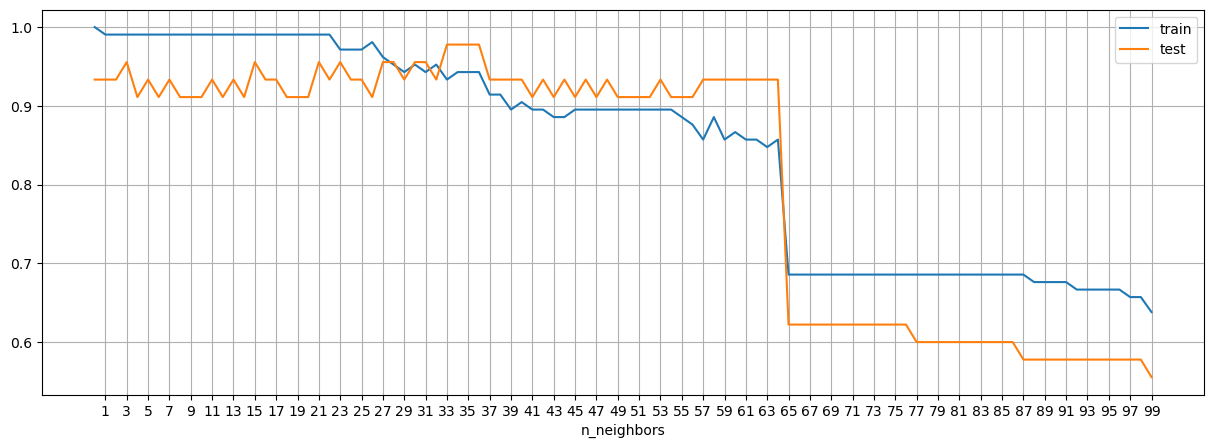

In [47]:
# 시각화를 통해서 훈련 점수와 평가점수 그래프화 시키기
plt.figure(figsize=(15,5)) # 그래프 사이즈 조절

plt.plot(train_score_list,label = 'train')
plt.plot(test_score_list,label = 'test')
plt.xticks(range(1,101,2)) # x축 눈금 값
plt.xlabel('n_neighbors') #x축 이름 붙이기
plt.grid() # 격자무늬 출력
plt.legend() # 범례 출력
plt.show()

In [52]:
# 수치로 직접 확인
train_arr = np.array(train_score_list)
test_arr = np.array(test_score_list)

In [53]:
train_arr - test_arr

array([ 0.06666667,  0.05714286,  0.05714286,  0.03492063,  0.07936508,
        0.05714286,  0.07936508,  0.05714286,  0.07936508,  0.07936508,
        0.07936508,  0.05714286,  0.07936508,  0.05714286,  0.07936508,
        0.03492063,  0.05714286,  0.05714286,  0.07936508,  0.07936508,
        0.07936508,  0.03492063,  0.05714286,  0.01587302,  0.03809524,
        0.03809524,  0.06984127,  0.00634921, -0.0031746 ,  0.00952381,
       -0.0031746 , -0.01269841,  0.01904762, -0.04444444, -0.03492063,
       -0.03492063, -0.03492063, -0.01904762, -0.01904762, -0.03809524,
       -0.02857143, -0.01587302, -0.03809524, -0.02539683, -0.04761905,
       -0.01587302, -0.03809524, -0.01587302, -0.03809524, -0.01587302,
       -0.01587302, -0.01587302, -0.01587302, -0.03809524, -0.01587302,
       -0.02539683, -0.03492063, -0.07619048, -0.04761905, -0.07619048,
       -0.06666667, -0.07619048, -0.07619048, -0.08571429, -0.07619048,
        0.06349206,  0.06349206,  0.06349206,  0.06349206,  0.06